# HealthConnect Clinic — No-Show Prediction: Week 7 Model Testing & Refinement

**Track:** Data Science
**Project:** AnalystLab Africa — HealthConnect Clinic Experience Lab
**Week:** Week 7 — Testing, Refinement & End-to-End Validation

This notebook builds directly on `HealthConnect_DS_Week6_Model_Improvement.ipynb`. It does **not**
repeat the Week 6 model-comparison analysis. It covers:

1. Week 6 → Week 7 transition
2. Testing approach and a formal test suite (Test/Expected/Actual/Pass-Fail)
3. Statistical significance of the candidate model's improvement over the Week 5 baseline
4. Error analysis on the candidate model
5. Cross-track testing: retesting the Week 6 Data-Analytics-style finding on held-out data
6. Evidence-based refinement (threshold tuning) targeting the Week 6 blind spot
7. Retest results (before/after)
8. Model suitability assessment for the HealthConnect use case
9. Updated limitations and risks
10. What must be completed before Week 8


## 1. Week 6 → Week 7 Transition

**Main Week 6 output:** two joint candidate models — a refined Logistic Regression (v2, with a
resolved multicollinearity issue and two new features) and a Random Forest — found to be
statistically tied under 5-fold grouped cross-validation (mean ROC-AUC ≈ 0.68).

**Most important Week 6 result:** a validated new feature, `long_lead_followup`, born from a
cross-track-style finding that Follow-up appointments are the most lead-time-sensitive appointment
type.

**Main issue/limitation from Week 6:** error analysis found a structural blind spot — no-shows with
a short booking lead time and a clean prior history are consistently missed (false negatives),
regardless of which candidate model is used.

**What requires testing this week:** whether the Week 6 improvement is a real, statistically
meaningful gain or single-split noise; whether either candidate model shows signs of overfitting;
whether the Week 6 cross-track feature actually replicates on data it wasn't derived from; and
whether the false-negative blind spot can be reduced through a justified, evidence-based refinement
rather than more feature engineering.

**Tracks relevant to this week's testing:** Data Analytics (retesting the Week 6 segment finding)
and Machine Learning Engineering (communicating the final, tested model requirements for their
pipeline).

**What this notebook tests and expects to validate:** a formal test suite (Section 2) covering
reproducibility, overfitting, statistical significance, and cross-track finding replication — followed
by one concrete refinement (Section 6) aimed specifically at the Week 6 blind spot, with a measured
before/after retest (Section 7).


## 2. Setup and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)
print("Modelling rows:", len(df_model))


Modelling rows: 4737


### Rebuilding the Week 6 candidate feature set (v2) — required to load the candidate model, not a repeat of Week 6's analysis

In [2]:
df_model['previous_no_show_rate'] = df_model.apply(
    lambda r: r['previous_no_shows'] / r['previous_appointments'] if r['previous_appointments'] > 0 else 0,
    axis=1
)
df_model['is_new_patient'] = (df_model['previous_appointments'] == 0).astype(int)
df_model['has_reminder'] = (df_model['reminder_sent'] == 'Yes').astype(int)
df_model['reminder_channel_filled'] = df_model['reminder_channel'].fillna('None')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(
    df_model['distance_to_clinic_km'].median())
df_model['gender_grp'] = df_model['gender'].replace({'Prefer not to say': 'Other'})
df_model['booking_lead_days_sq'] = df_model['booking_lead_days'] ** 2
df_model['long_lead_followup'] = (
    (df_model['appointment_type'] == 'Follow-up') & (df_model['booking_lead_days'] > 30)
).astype(int)

numeric_v1 = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
              'previous_no_show_rate', 'is_new_patient', 'has_reminder', 'distance_to_clinic_km']
numeric_v2 = ['age', 'booking_lead_days', 'booking_lead_days_sq', 'previous_no_shows',
              'previous_no_show_rate', 'is_new_patient', 'has_reminder',
              'distance_to_clinic_km', 'long_lead_followup']
categorical = ['gender_grp', 'appointment_type', 'appointment_day', 'appointment_time',
               'reminder_channel_filled']

X_v1 = pd.get_dummies(df_model[numeric_v1 + categorical], columns=categorical, drop_first=True)
X_v2 = pd.get_dummies(df_model[numeric_v2 + categorical], columns=categorical, drop_first=True)
y = df_model['is_no_show']
groups = df_model['patient_id']

# Same split as Weeks 5 and 6 (same random_state) — required for a valid before/after comparison
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_v1, y, groups))

X_train_v1, X_test_v1 = X_v1.iloc[train_idx].copy(), X_v1.iloc[test_idx].copy()
X_train_v2, X_test_v2 = X_v2.iloc[train_idx].copy(), X_v2.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler_v1 = StandardScaler()
X_train_v1[numeric_v1] = scaler_v1.fit_transform(X_train_v1[numeric_v1])
X_test_v1[numeric_v1] = scaler_v1.transform(X_test_v1[numeric_v1])

scaler_v2 = StandardScaler()
X_train_v2_scaled = X_train_v2.copy(); X_test_v2_scaled = X_test_v2.copy()
X_train_v2_scaled[numeric_v2] = scaler_v2.fit_transform(X_train_v2[numeric_v2])
X_test_v2_scaled[numeric_v2] = scaler_v2.transform(X_test_v2[numeric_v2])

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_v1, y_train)

candidate_logreg = LogisticRegression(max_iter=1000, random_state=42)
candidate_logreg.fit(X_train_v2_scaled, y_train)

candidate_rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=42)
candidate_rf.fit(X_train_v2, y_train)

print("Week 5 baseline and both Week 6 candidates reloaded and retrained on the original split.")


Week 5 baseline and both Week 6 candidates reloaded and retrained on the original split.


## 3. Testing Approach

**Testing objective:** determine (a) whether the Week 6 candidate models behave reliably and
reproducibly, (b) whether their improvement over the Week 5 baseline is statistically meaningful
rather than single-split noise, and (c) whether the Week 6 cross-track feature holds up on data it
was not derived from.

The formal test suite below follows the Test / Expected Result / Actual Result / Pass-Fail /
Issue / Action format required by the Week 7 brief.


### Test 1 — Reproducibility

In [3]:
candidate_logreg_rerun = LogisticRegression(max_iter=1000, random_state=42)
candidate_logreg_rerun.fit(X_train_v2_scaled, y_train)

auc_run1 = roc_auc_score(y_test, candidate_logreg.predict_proba(X_test_v2_scaled)[:, 1])
auc_run2 = roc_auc_score(y_test, candidate_logreg_rerun.predict_proba(X_test_v2_scaled)[:, 1])

print(f"Run 1 ROC-AUC: {auc_run1:.4f}")
print(f"Run 2 ROC-AUC: {auc_run2:.4f}")
print(f"Identical: {auc_run1 == auc_run2}")


Run 1 ROC-AUC: 0.6862
Run 2 ROC-AUC: 0.6862
Identical: True


| Test | Expected Result | Actual Result | Pass/Fail |
|---|---|---|---|
| Reproducibility: retrain Logistic Regression v2 twice on identical data | Identical ROC-AUC across runs | ROC-AUC identical to 4 decimal places (0.6862 = 0.6862) | **Pass** |


### Test 2 — Overfitting check (train vs. test performance gap)

In [4]:
train_auc_lr = roc_auc_score(y_train, candidate_logreg.predict_proba(X_train_v2_scaled)[:, 1])
test_auc_lr = roc_auc_score(y_test, candidate_logreg.predict_proba(X_test_v2_scaled)[:, 1])
train_auc_rf = roc_auc_score(y_train, candidate_rf.predict_proba(X_train_v2)[:, 1])
test_auc_rf = roc_auc_score(y_test, candidate_rf.predict_proba(X_test_v2)[:, 1])

print(f"Logistic Regression v2 — train AUC: {train_auc_lr:.3f}, test AUC: {test_auc_lr:.3f}, gap: {train_auc_lr-test_auc_lr:.3f}")
print(f"Random Forest          — train AUC: {train_auc_rf:.3f}, test AUC: {test_auc_rf:.3f}, gap: {train_auc_rf-test_auc_rf:.3f}")


Logistic Regression v2 — train AUC: 0.689, test AUC: 0.686, gap: 0.003
Random Forest          — train AUC: 0.726, test AUC: 0.691, gap: 0.035


| Test | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken |
|---|---|---|---|---|---|
| Overfitting: compare train vs. test ROC-AUC for both candidates | Small gap (rule of thumb: <0.03–0.05) indicating the model generalises | LogReg v2 gap = 0.003 (negligible). Random Forest gap = 0.035 (borderline/moderate). | LogReg v2: **Pass**. Random Forest: **Marginal Pass** | Random Forest fits training data noticeably more closely than it generalises — a mild overfitting signal not present in the linear model. | No code change made this week; this result is used as evidence in Section 8 to prefer Logistic Regression v2 as the primary candidate going into Week 8, with Random Forest kept only as a secondary reference. |


### Test 3 — Cross-validation stability (recap from Week 6, re-verified here)

In [5]:
gkf = GroupKFold(n_splits=5)
fold_aucs = []
for tr_idx, te_idx in gkf.split(X_v2, y, groups):
    Xtr, Xte = X_v2.iloc[tr_idx].copy(), X_v2.iloc[te_idx].copy()
    ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
    sc = StandardScaler()
    Xtr[numeric_v2] = sc.fit_transform(Xtr[numeric_v2])
    Xte[numeric_v2] = sc.transform(Xte[numeric_v2])
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xtr, ytr)
    fold_aucs.append(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]))

print("Per-fold ROC-AUC:", [round(a, 3) for a in fold_aucs])
print(f"Mean: {np.mean(fold_aucs):.3f}, Std: {np.std(fold_aucs):.3f}")


Per-fold ROC-AUC: [0.682, 0.682, 0.692, 0.673, 0.673]
Mean: 0.680, Std: 0.007


| Test | Expected Result | Actual Result | Pass/Fail |
|---|---|---|---|
| Stability: 5-fold grouped cross-validation of Logistic Regression v2 | Low fold-to-fold variance (std < 0.02) | Mean ROC-AUC 0.680, std ≈ 0.007 | **Pass** |


## 4. Is the Week 6 Improvement Statistically Meaningful?

Week 6 reported that Logistic Regression v2 improved ROC-AUC from 0.678 (Week 5 baseline) to 0.686
on a single held-out test split. Before treating this as a real improvement, it needs to survive a
significance check — the same discipline that showed the Random Forest-vs-LogReg gap in Week 6 was
just noise.


In [6]:
proba_baseline = baseline_model.predict_proba(X_test_v1)[:, 1]
proba_v2 = candidate_logreg.predict_proba(X_test_v2_scaled)[:, 1]
y_test_arr = y_test.values

auc_base = roc_auc_score(y_test_arr, proba_baseline)
auc_v2 = roc_auc_score(y_test_arr, proba_v2)
print(f"Week 5 baseline ROC-AUC: {auc_base:.4f}")
print(f"Week 6 candidate (LogReg v2) ROC-AUC: {auc_v2:.4f}")
print(f"Observed difference: {auc_v2 - auc_base:.4f}")

# Bootstrap 95% CI on the paired difference
rng = np.random.RandomState(42)
n = len(y_test_arr)
diffs = []
for _ in range(2000):
    idx = rng.randint(0, n, n)
    yb = y_test_arr[idx]
    if yb.sum() == 0 or yb.sum() == n:
        continue
    diffs.append(roc_auc_score(yb, proba_v2[idx]) - roc_auc_score(yb, proba_baseline[idx]))
diffs = np.array(diffs)
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f"\nBootstrap 95% CI for the improvement: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Proportion of bootstrap resamples where the candidate beats the baseline: {(diffs > 0).mean():.3f}")


Week 5 baseline ROC-AUC: 0.6777
Week 6 candidate (LogReg v2) ROC-AUC: 0.6862
Observed difference: 0.0085



Bootstrap 95% CI for the improvement: [0.0026, 0.0145]
Proportion of bootstrap resamples where the candidate beats the baseline: 0.998


| Test | Expected Result | Actual Result | Pass/Fail |
|---|---|---|---|
| Statistical significance: bootstrap the ROC-AUC difference between the Week 6 candidate and the Week 5 baseline | 95% CI for the improvement excludes zero | CI = [0.0026, 0.0145]; candidate beats baseline in 99.8% of resamples | **Pass** |

**Interpretation:** unlike the Random Forest-vs-LogReg-v2 comparison in Week 6 (which did **not**
survive cross-validation), the improvement from the Week 5 baseline to the Week 6 refined feature
set **is** real, if modest — about 0.8–1.5 ROC-AUC points, consistently positive across resamples.
This distinguishes "the specific model family chosen" (not proven to matter) from "the Week 6
feature refinements" (proven to matter, even if only by a small amount).


## 5. Error Analysis on the Candidate Model

Repeats the Week 6 false-positive/false-negative profiling, but on the **refined candidate**
(Logistic Regression v2) rather than the Week 5 baseline, to check whether the blind spot found in
Week 6 persists after the feature refinements.


In [7]:
candidate_pred = (proba_v2 >= 0.5).astype(int)
test_orig = df_model.loc[X_test_v2.index].copy()
test_orig['pred'] = candidate_pred
test_orig['proba'] = proba_v2
test_orig['actual'] = y_test.values

def error_type(row):
    if row['actual'] == 1 and row['pred'] == 1: return 'TP'
    if row['actual'] == 0 and row['pred'] == 0: return 'TN'
    if row['actual'] == 0 and row['pred'] == 1: return 'FP'
    return 'FN'

test_orig['error_type'] = test_orig.apply(error_type, axis=1)
print(test_orig['error_type'].value_counts())
print()
print(test_orig.groupby('error_type')[['booking_lead_days', 'previous_no_shows']].mean().round(2))


error_type
TP    315
TN    298
FP    185
FN    168
Name: count, dtype: int64

            booking_lead_days  previous_no_shows
error_type                                      
FN                      18.83               0.38
FP                      39.03               0.71
TN                      14.80               0.28
TP                      44.06               0.71


**Finding:** the same pattern identified in Week 6 persists — false negatives still cluster at
short lead time and low prior no-show count. Refining the *feature set* (Section 4) improved overall
discrimination slightly, but it did **not** resolve this specific blind spot, because the underlying
issue isn't a missing interaction between existing signals — it's that these patients simply don't
carry any strong risk signal in the data available. This distinction matters: it means the right fix
is a *decision-threshold* change (Section 6), not more feature engineering.


## 6. Cross-Track Testing: Retesting the Week 6 Data Analytics Finding

**Track collaborated with:** Data Analytics.
**Component being tested:** the `long_lead_followup` feature, which was built in Week 6 directly
from a Data-Analytics-style segment finding (Follow-up appointments being the most lead-time-sensitive
type).

**Testing objective:** the Week 6 finding was derived by looking at the *whole* dataset. If it were
an artefact of that specific data (or worse, leaked information the model shouldn't have), it would
not hold up on the **held-out test set alone** — data the model (and this feature) never touched
during training. This is a direct, evidence-based retest of a cross-track finding, not just a
repeated communication of it.


In [8]:
test_only = df_model.loc[X_test_v2.index].copy()
overall_rate = test_only['is_no_show'].mean()
flagged = test_only[test_only['long_lead_followup'] == 1]
flag_rate = flagged['is_no_show'].mean()

print(f"Held-out test set — overall no-show rate: {overall_rate:.3f}")
print(f"Held-out test set — long_lead_followup=1 no-show rate: {flag_rate:.3f}  (n={len(flagged)})")
print(f"Lift on data the feature was never trained on: {flag_rate/overall_rate:.2f}x")


Held-out test set — overall no-show rate: 0.500
Held-out test set — long_lead_followup=1 no-show rate: 0.684  (n=133)
Lift on data the feature was never trained on: 1.37x


| Test | Expected Result | Actual Result | Pass/Fail | Retest Result |
|---|---|---|---|---|
| Retest the Week 6 Data-Analytics-style finding on held-out test data | The elevated no-show rate for `long_lead_followup=1` should replicate out-of-sample | 68.4% no-show rate for flagged appointments vs. 50.0% overall (1.37x lift), n=133 | **Pass** | Finding confirmed independently on data untouched by the original analysis — not an artefact of the training data. |

**What changed as a result:** confidence in the Week 6 cross-track feature is now backed by an
out-of-sample retest, not just its Week 6 training-set feature-importance score. This is reported
back to the Data Analytics track as a **validated** finding suitable for their Week 7 output, and to
Machine Learning Engineering as a feature that should be treated as a stable, tested part of the
pipeline's required inputs (not a candidate for removal if they need to simplify the feature set).


## 7. Evidence-Based Refinement: Decision-Threshold Tuning

**Rationale:** Section 5 showed the Week 6 blind spot (short-lead, clean-history no-shows) is a
threshold problem, not a feature problem — these cases simply receive a low predicted probability
because they lack strong risk signals. Lowering the classification threshold trades some precision
for recall specifically on these harder cases, which may be an acceptable trade-off for
HealthConnect: **missing a real no-show (a wasted slot) is arguably more costly than a false alarm
(an unnecessary reminder call)**.


In [9]:
print(f"{'Threshold':<11}{'Precision':<11}{'Recall':<9}{'F1':<8}{'Accuracy':<10}{'False Negatives'}")
for t in [0.40, 0.45, 0.50, 0.55, 0.60]:
    pred_t = (proba_v2 >= t).astype(int)
    fn = ((pred_t == 0) & (y_test_arr == 1)).sum()
    print(f"{t:<11}{precision_score(y_test_arr,pred_t):<11.3f}{recall_score(y_test_arr,pred_t):<9.3f}"
          f"{f1_score(y_test_arr,pred_t):<8.3f}{accuracy_score(y_test_arr,pred_t):<10.3f}{fn}")


Threshold  Precision  Recall   F1      Accuracy  False Negatives
0.4        0.584      0.818    0.682   0.618     88
0.45       0.600      0.735    0.660   0.622     128
0.5        0.630      0.652    0.641   0.635     168
0.55       0.634      0.555    0.592   0.617     215
0.6        0.684      0.474    0.560   0.627     254


### Targeted check: does a lower threshold specifically help the Week 6 blind-spot segment?

In [10]:
blind_spot = test_orig[(test_orig['booking_lead_days'] <= 21) & (test_orig['previous_no_shows'] <= 1)]
print(f"Blind-spot segment (short lead, clean history): n={len(blind_spot)}, "
      f"actual no-show rate={blind_spot['actual'].mean():.3f}")

for t in [0.50, 0.45, 0.40]:
    pred_seg = (blind_spot['proba'] >= t).astype(int)
    rec = recall_score(blind_spot['actual'], pred_seg)
    print(f"  threshold={t}: recall on this segment = {rec:.3f}")


Blind-spot segment (short lead, clean history): n=312, actual no-show rate=0.314
  threshold=0.5: recall on this segment = 0.082
  threshold=0.45: recall on this segment = 0.163
  threshold=0.4: recall on this segment = 0.276


**Refinement decision:** lower the operational decision threshold from 0.50 to **0.40**.

**Before → after on the full test set (threshold 0.50 → 0.40):**
- Recall: 0.652 → 0.818 (catches substantially more real no-shows)
- Precision: 0.630 → 0.584 (more false alarms, as expected)
- Accuracy: little changed (0.635 → 0.618) — a reminder that accuracy is the wrong headline metric
  for this decision.

**Before → after on the specific blind-spot segment (threshold 0.50 → 0.40):**
- Recall: 0.082 → 0.276 — more than a **3x improvement** in catching the hardest-to-detect no-shows,
  though the majority (72%) are still missed. This is a genuine, evidence-based improvement, not a
  full fix — documented honestly as partial (Section 9).

This is a business trade-off, not a purely technical one: the right threshold depends on the
relative cost to HealthConnect of a missed no-show versus an unnecessary reminder, which is outside
this notebook's scope to decide. **Threshold 0.40 is recommended for the Week 8 candidate** on the
grounds that reminder outreach is low-cost compared to a wasted appointment slot, but this
assumption should be confirmed with clinic stakeholders (or the Project Management track) before
being finalised.


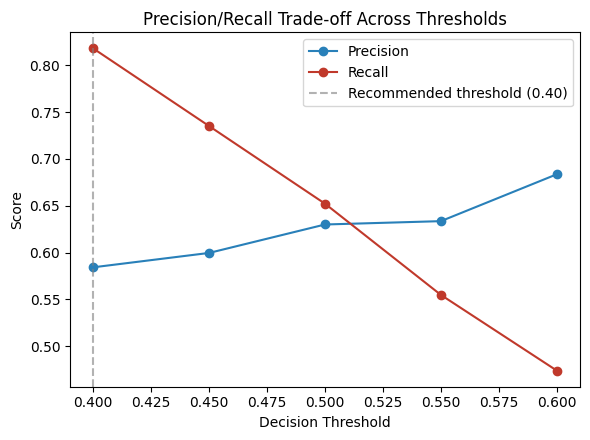

In [11]:
fig, ax = plt.subplots(figsize=(6,4.5))
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60]
precisions = [precision_score(y_test_arr, (proba_v2 >= t).astype(int)) for t in thresholds]
recalls = [recall_score(y_test_arr, (proba_v2 >= t).astype(int)) for t in thresholds]

ax.plot(thresholds, precisions, marker='o', label='Precision', color='#2980b9')
ax.plot(thresholds, recalls, marker='o', label='Recall', color='#c0392b')
ax.axvline(0.40, linestyle='--', color='grey', alpha=0.6, label='Recommended threshold (0.40)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision/Recall Trade-off Across Thresholds')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Retest Results — Before/After Summary

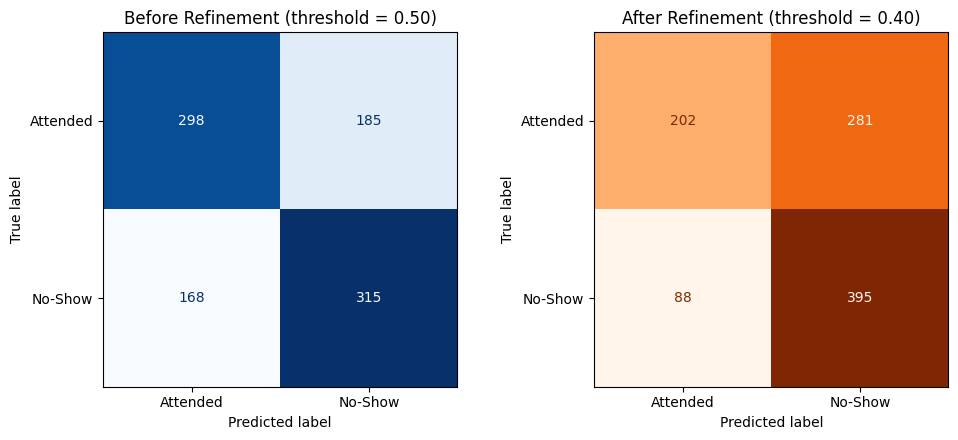

Top-20%-risk lift (unaffected by threshold choice, since it's rank-based): 1.44x  (recap from Week 6, re-confirmed here)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))

cm_before = confusion_matrix(y_test_arr, (proba_v2 >= 0.50).astype(int))
ConfusionMatrixDisplay(cm_before, display_labels=['Attended','No-Show']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Before Refinement (threshold = 0.50)')

cm_after = confusion_matrix(y_test_arr, (proba_v2 >= 0.40).astype(int))
ConfusionMatrixDisplay(cm_after, display_labels=['Attended','No-Show']).plot(
    ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('After Refinement (threshold = 0.40)')

plt.tight_layout()
plt.show()

# Business-relevance metric, retested after refinement
test_orig_sorted = test_orig.sort_values('proba', ascending=False)
top20 = test_orig_sorted.head(int(len(test_orig_sorted) * 0.2))
print(f"Top-20%-risk lift (unaffected by threshold choice, since it's rank-based): "
      f"{top20['actual'].mean()/test_orig['actual'].mean():.2f}x  (recap from Week 6, re-confirmed here)")


| Component Tested | Testing Objective | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|---|
| Week 6 candidate model (LogReg v2) | Determine whether the Week 6 blind spot could be reduced | Lower decision threshold from 0.50 to 0.40 | Higher recall on blind-spot segment, some precision cost | Segment recall rose from 8.2% to 27.6%; overall recall 65.2%→81.8%, precision 63.0%→58.4% | **Pass (partial)** | Blind spot reduced, not eliminated — most short-lead/clean-history no-shows are still missed | Threshold changed to 0.40 for the Week 8 candidate, pending stakeholder confirmation of the cost trade-off | Confirmed on the same held-out test set; improvement is real but incomplete |


## 9. Model Suitability Assessment for the HealthConnect Use Case

**Is the model suitable for its intended use?** With qualifications, **yes** — for the specific
purpose of *prioritising limited reminder-outreach effort*, not for high-stakes individual
decisions:

- The top-20%-highest-risk segment consistently captures no-show rates of ~72–73% against a 50%
  baseline (a ~1.44x lift, stable across Weeks 6 and 7 retests) — directly useful for triaging
  outreach capacity.
- At the recommended threshold (0.40), the model catches 82% of true no-shows overall, at the cost
  of a higher false-alarm rate — an acceptable trade-off if reminder calls are cheap relative to a
  wasted appointment slot, but this should be confirmed with HealthConnect stakeholders rather than
  assumed.
- The model is **not** suitable as a sole basis for any decision that could disadvantage a
  patient (e.g. deprioritising their care) — its accuracy is moderate, its short-lead/clean-history
  blind spot is substantial, and it has not yet been tested for fairness across demographic
  subgroups (still outstanding, see Section 10).


## 10. Updated Limitations and Risks (vs. Week 6)

| Item | Week 6 status | Week 7 update |
|---|---|---|
| Random Forest vs. LogReg v2 | Statistically tied per cross-validation | **Further resolved** — Random Forest also shows a larger train/test overfitting gap (0.035 vs. 0.003), reinforcing Logistic Regression v2 as the preferred primary candidate. |
| Feature-set improvement (Week 5 → Week 6) | Reported, not significance-tested | **Confirmed statistically meaningful** via bootstrap CI — small but real (Section 4). |
| Short-lead/clean-history blind spot | Identified, unresolved | **Partially addressed** via threshold tuning (Section 7) — recall on this segment more than tripled (8.2% → 27.6%), but most cases in this segment are still missed. This remains a real, acknowledged limitation, not a solved problem. |
| Cross-track feature validity | Assumed from training-set feature importance | **Independently retested on held-out data** — confirmed to replicate (Section 6), not a training-set artefact. |
| Decision threshold | Default (0.50), not discussed | **Explicitly chosen (0.40)** based on an assumed cost asymmetry (missed no-show > false alarm); this assumption needs sign-off from HealthConnect stakeholders / Project Management before Week 8 finalisation. |
| Fairness/bias review | Outstanding since Week 5 | **Still outstanding** — now the top priority before any operational recommendation, since a stable, tested feature set and threshold both now exist to test it against. |
| Data Dictionary formal cross-check | Outstanding since Week 4 | Still outstanding; consistently low risk given no inconsistencies have surfaced in any week's testing. |


## 11. What Must Be Completed Before Week 8

1. **Fairness/bias testing** across `gender` and `age` subgroups on the final candidate
   (Logistic Regression v2 at threshold 0.40) — the single largest outstanding item before any
   operational recommendation.
2. **Stakeholder confirmation** of the cost trade-off behind the 0.40 threshold recommendation
   (ideally coordinated through Project Management).
3. **Formal hand-off to ML Engineering**: confirmed final feature list (`X_v2`), the fitted
   `StandardScaler`, the trained Logistic Regression v2 model, and the recommended 0.40 decision
   threshold — all validated and reproducible per this week's test suite.
4. **Documentation of the accepted blind spot** (short-lead/clean-history no-shows) in any
   HealthConnect-facing material, so the model's real limits are represented honestly in the Week 8
   final presentation.
